In [1]:
import sys
from pathlib import Path

# Get the top-level project directory relative to this notebook/script
BASE_DIR = Path(__file__).parent if "__file__" in globals() else Path.cwd()
TOP_DIR = BASE_DIR.parent  # adjust depending on your structure

sys.path.insert(0, str(TOP_DIR / "d2l"))

In [2]:
import torch
from torch import nn
from d2l import torch as d2l

In [18]:
class KeraMLPs(d2l.Classifier):
    def __init__(self, lr=0.1):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(), nn.LazyLinear(300), nn.ReLU(), nn.LazyLinear(100), nn.ReLU(), nn.LazyLinear(10), nn.Softmax(dim=1))
        self.net.apply(d2l.init_cnn)

In [14]:
KeraMLPs().layer_summary((28, 28))

Flatten output shape:	 torch.Size([28, 28])
Linear output shape:	 torch.Size([28, 300])
ReLU output shape:	 torch.Size([28, 300])
Linear output shape:	 torch.Size([28, 100])
ReLU output shape:	 torch.Size([28, 100])
Linear output shape:	 torch.Size([28, 10])
Softmax output shape:	 torch.Size([28, 10])


In [19]:
model = KeraMLPs(lr=0.01)
data = d2l.FashionMNIST(batch_size=128, resize=(28, 28))
trainer = d2l.Trainer(max_epochs=30, num_gpus=1)

CPU times: total: 4min 9s
Wall time: 6min 4s


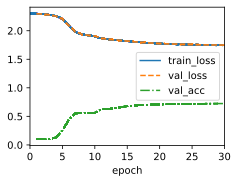

In [20]:
%%time
trainer.fit(model, data)